# Plot results for offline prompting in the "farm" example

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FixedFormatter, FixedLocator
import numpy as np
import seaborn as sns
import os

In [3]:
results_folder = Path("generated_adaptations/farm")
# results_folder = Path("generated_adaptations/old/251015/farm")
pd.options.display.float_format = "{:,.1f}".format
sns.set_theme()

## Run experiments

In [4]:
prompts = {
    # "default": "generated_adaptations/prompts_user/farm_strategy.md",
    "coverage": "generated_adaptations/prompts_user/farm_strategy.md",
    # "state": "generated_adaptations/prompts_user/farm_strategy_state.md",
    "reasons": "generated_adaptations/prompts_user/farm_reasons.md",
}
variants = {
    "system": "system",
    "constraints": "all",
    # "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 1
start = 6

In [5]:
# import generated_adaptations.generator as generator

In [6]:
env = os.environ.copy()
env["PYTHONPATH"] = env.get("PYTHONPATH", "") + os.pathsep + os.getcwd()

for prompt_name, prompt in prompts.items():
    for variant, mode in variants.items():
        for llm_name, llm in llms.items():
            for repeat in range(start, start + repeats):
                folder_name = f"{llm_name}_{repeat:02d}"
                print(f"\n{variant}_{prompt_name}/{folder_name}\n")
                folder = results_folder / f"{variant}_{prompt_name}" / folder_name
                folder.mkdir(parents=True, exist_ok=True)
                shutil.copy(prompt, folder / "01_user.md")
                cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
                result = subprocess.run(cmd, capture_output=True, text=True, env=env)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
                print(result.stdout)
                print(result.stderr)
                # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system_coverage/5nano_06

Loaded 2 messages from generated_adaptations\farm\system_coverage\5nano_06.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1024, Output: 7010 (reasoning: 5888)
Response time (seconds): 61.7

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\farm\system_coverage\5nano_06\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_06/code_02 --variant=system_coverage --tests=system
Test exit code: 0
Running tests (functional): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_06/code_02 --variant=system_coverage --tests=functional
Test exit code: 1
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_06/code_02 --variant=system_coverage --tests=all
Test exit code: 

## Results

In [4]:
folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("41mini_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]

folders = [f for f in folders if "mock" not in f.parent.stem]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints_coverage', '5mini_01'), ('constraints_coverage', '5mini_02'), ('constraints_coverage', '5mini_03'), ('constraints_coverage', '5mini_04'), ('constraints_coverage', '5mini_05'), ('constraints_coverage', '5mini_06'), ('constraints_coverage', '5nano_01'), ('constraints_coverage', '5nano_02'), ('constraints_coverage', '5nano_03'), ('constraints_coverage', '5nano_04'), ('constraints_coverage', '5nano_05'), ('constraints_coverage', '5nano_06'), ('constraints_reasons', '5mini_01'), ('constraints_reasons', '5mini_02'), ('constraints_reasons', '5mini_03'), ('constraints_reasons', '5mini_04'), ('constraints_reasons', '5mini_05'), ('constraints_reasons', '5mini_06'), ('constraints_reasons', '5nano_01'), ('constraints_reasons', '5nano_02'), ('constraints_reasons', '5nano_03'), ('constraints_reasons', '5nano_04'), ('constraints_reasons', '5nano_05'), ('constraints_reasons', '5nano_06'), ('result_coverage', '5mini_01'), ('result_coverage', '5mini_02'), ('result_coverage', '5mini_03'), 

In [5]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "pass"
        elif "_functional_fail" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "fail"
        elif "_functional_pass" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            result = results["damage"]
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")
summary.fillna("", inplace=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_32188\473530000.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.fillna("", inplace=True)


In [6]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [7]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [8]:
summary

02_all 02_functional 02_result 02_system  \
llm   params               repeat                                            
5mini constraints_coverage 01       fail          fail     134.7      pass   
                           02       fail          fail     127.0      pass   
                           03       fail          fail     127.0      pass   
                           04       fail          fail     129.7      pass   
                           05       fail          fail     127.0      pass   
...                                  ...           ...       ...       ...   
5nano system_reasons       02       pass          pass      37.0      pass   
                           03       fail          fail     167.3      pass   
                           04       fail          fail      54.3      pass   
                           05       pass          pass      41.7      pass   
                           06       fail          fail     136.7      fail   

                                  04_all 04_functional 04_result 04_system  \
llm   params               repeat                                            
5mini constraints_coverage 01       pass          pass      54.3      pass   
                           02                                      missing   
                           03       pass          pass     115.7      pass   
                           04       pass          pass      71.3      pass   
                           05       fail          fail     202.0      pass   
...                                  ...           ...       ...       ...   
5nano system_reasons       02                                                
                           03       fail          fail     167.3      pass   
                           04       fail          fail     273.3      pass   
                           05                                                
                           06       fail          fail     149.0      pass   

                                  06_all 06_functional  ... 16_result  \
llm   params               repeat                       ...             
5mini constraints_coverage 01                           ...             
                           02                           ...             
                           03       fail          fail  ...             
                           04       fail          fail  ...             
                           05       pass          pass  ...             
...                                  ...           ...  ...       ...   
5nano system_reasons       02                           ...             
                           03       fail          fail  ...     253.0   
                           04       fail          fail  ...     150.3   
                           05                           ...             
                           06       fail          fail  ...     190.0   

                                  16_system 18_all 18_functional 18_result  \
llm   params               repeat                                            
5mini constraints_coverage 01                                                
                           02                                                
                           03                                                
                           04                                                
                           05                                                
...                                     ...    ...           ...       ...   
5nano system_reasons       02                                                
                           03          fail   fail          fail     296.3   
                           04          pass   fail          fail     152.7   
                           05                                                
                           06          pass   fail          fail     190.0   

                                  18_sy

### Plot

In [9]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}
colors = {
    "5nano/constraints_state": "tab:blue",
    "5nano/constraints_default": "tab:cyan",
    "5nano/system_state": "tab:green",
    "5nano/system_default": "tab:olive",
    "5nano/result_state": "tab:orange",
    "5nano/result_default": "tab:brown",
    "5nano/stats_state": "tab:red",
    "5nano/stats_default": "tab:pink",
}
colors = {
    "5nano/constraints_default": "tab:blue",
    "5mini/constraints_default": "tab:cyan",
    "5nano/system_default": "tab:green",
    "5mini/system_default": "tab:olive",
    "5nano/result_default": "tab:orange",
    "5mini/result_default": "tab:brown",
    # "5nano/stats_default": "tab:red",
    # "5mini/stats_default": "tab:pink",
    "5nano/constraints_coverage": "tab:blue",
    "5mini/constraints_coverage": "tab:cyan",
    "5nano/system_coverage": "tab:green",
    "5mini/system_coverage": "tab:olive",
    "5nano/result_coverage": "tab:orange",
    "5mini/result_coverage": "tab:brown",
}

In [10]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_32188\65529393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params               repeat                                               
5mini constraints_coverage 01          134.7       54.3        NaN        NaN   
                           02          127.0        NaN        NaN       83.0   
                           03          127.0      115.7       31.3       50.0   
                           04          129.7       71.3      140.3       51.0   
                           05          127.0      202.0       54.3        NaN   
...                                      ...        ...        ...        ...   
5nano system_reasons       02           37.0        NaN        NaN        NaN   
                           03          167.3      167.3      305.7      305.7   
                           04           54.3      273.3        NaN      259.3   
                           05           41.7        NaN        NaN        NaN   
                           06          136.7      149.0      276.3      276.3   

                                   10_result  12_result  14_result  16_result  \
llm   params               repeat                                               
5mini constraints_coverage 01            NaN        NaN        NaN        NaN   
                           02            NaN      129.3       47.7        NaN   
                           03            NaN        NaN        NaN        NaN   
                           04            NaN        NaN        NaN        NaN   
                           05            NaN        NaN        NaN        NaN   
...                                      ...        ...        ...        ...   
5nano system_reasons       02            NaN        NaN        NaN        NaN   
                           03          305.7      296.3      299.3      253.0   
                           04          259.3      259.3      217.7      150.3   
                           05            NaN        NaN        NaN        NaN   
                           06          276.3      276.3      209.3      190.0   

                                   18_result  20_result  
llm   params               repeat                        
5mini constraints_coverage 01            NaN        NaN  
                           02            NaN        NaN  
                           03            NaN        NaN  
                           04            NaN        NaN  
                           05            NaN        NaN  
...                                      ...        ...  
5nano system_reasons       02            NaN        NaN  
                           03          296.3      296.3  
                           04          152.7      147.3  
                           05            NaN        NaN  
                           06          190.0      182.3  

[72 rows x 10 columns]

In [11]:
stop_by_constraints = plot_data.copy()

def clear_after_pass(row):
    passed = False

    for col in row.index:
        if not passed:
            constraints_col = col.replace('_result', '_all')
            if summary.loc[row.name, constraints_col] == "pass":
                passed = True
        else:
            row[col] = np.nan
    return row

stop_by_constraints = stop_by_constraints.apply(clear_after_pass, axis=1)
plot_data = stop_by_constraints
stop_by_constraints

02_result  04_result  06_result  08_result  \
llm   params               repeat                                               
5mini constraints_coverage 01          134.7       54.3        NaN        NaN   
                           02          127.0        NaN        NaN       83.0   
                           03          127.0      115.7        NaN        NaN   
                           04          129.7       71.3        NaN        NaN   
                           05          127.0      202.0       54.3        NaN   
...                                      ...        ...        ...        ...   
5nano system_reasons       02           37.0        NaN        NaN        NaN   
                           03          167.3      167.3      305.7      305.7   
                           04           54.3      273.3        NaN      259.3   
                           05           41.7        NaN        NaN        NaN   
                           06          136.7      149.0      276.3      276.3   

                                   10_result  12_result  14_result  16_result  \
llm   params               repeat                                               
5mini constraints_coverage 01            NaN        NaN        NaN        NaN   
                           02            NaN        NaN        NaN        NaN   
                           03            NaN        NaN        NaN        NaN   
                           04            NaN        NaN        NaN        NaN   
                           05            NaN        NaN        NaN        NaN   
...                                      ...        ...        ...        ...   
5nano system_reasons       02            NaN        NaN        NaN        NaN   
                           03          305.7      296.3      299.3      253.0   
                           04          259.3      259.3      217.7      150.3   
                           05            NaN        NaN        NaN        NaN   
                           06          276.3      276.3      209.3      190.0   

                                   18_result  20_result  
llm   params               repeat                        
5mini constraints_coverage 01            NaN        NaN  
                           02            NaN        NaN  
                           03            NaN        NaN  
                           04            NaN        NaN  
                           05            NaN        NaN  
...                                      ...        ...  
5nano system_reasons       02            NaN        NaN  
                           03          296.3      296.3  
                           04          152.7      147.3  
                           05            NaN        NaN  
                           06          190.0      182.3  

[72 rows x 10 columns]

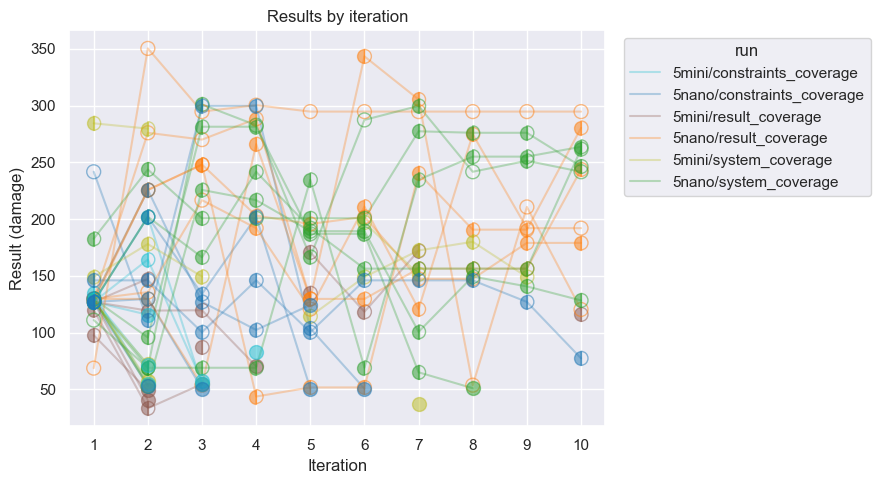

In [12]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    label_no_repeat = label.rsplit("/", 1)[0]
    # color = colors[label.rsplit("/", 1)[0].rsplit("_", 1)[0]]
    if label_no_repeat not in colors:
        continue

    color = colors[label_no_repeat]
    if label_no_repeat in ax.get_legend_handles_labels()[1]:
        label_no_repeat = None
    line, = ax.plot(x, y, '-', label=label_no_repeat, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        functional_col = result_col.replace('_result', '_functional')
        all_col = result_col.replace('_result', '_all')

        system = summary.loc[col, system_col]
        functional = summary.loc[col, functional_col] if functional_col in summary.columns else summary.loc[col, all_col]

        if system == "pass" and functional == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 5 if "constraints" in label else 3,
        "s": 100, "alpha": 0.5
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (damage)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iterations counts

In [13]:
def last_value_index(row):
    last_index = 0
    for i, col in enumerate(row.index, start=1):
        if not np.isnan(row[col]):
            last_index = i
    return last_index

iterations = plot_data.apply(last_value_index, axis=1)
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations = iterations.reset_index()
iterations

,llm,params,repeat,iterations
0,5mini,constraints_coverage,01,2
1,5mini,constraints_coverage,02,4
2,5mini,constraints_coverage,03,2
3,5mini,constraints_coverage,04,2
4,5mini,constraints_coverage,05,3
...,...,...,...,...
67,5nano,system_reasons,02,1
68,5nano,system_reasons,03,10
69,5nano,system_reasons,04,10
70,5nano,system_reasons,05,1


<Axes: xlabel='iterations', ylabel='params'>

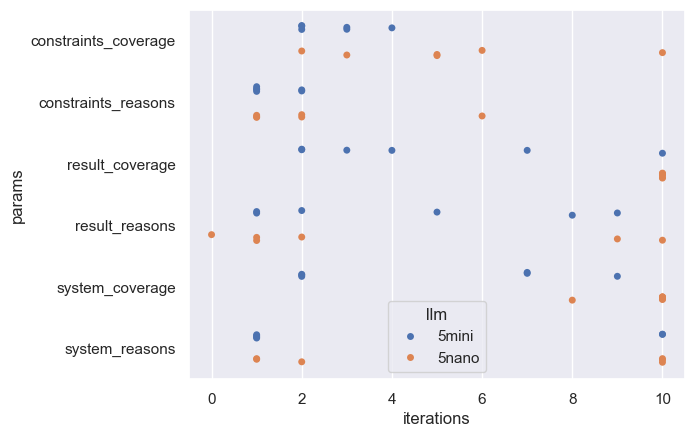

In [14]:
sns.stripplot(x="iterations", y="params", hue="llm", data=iterations, dodge=True)

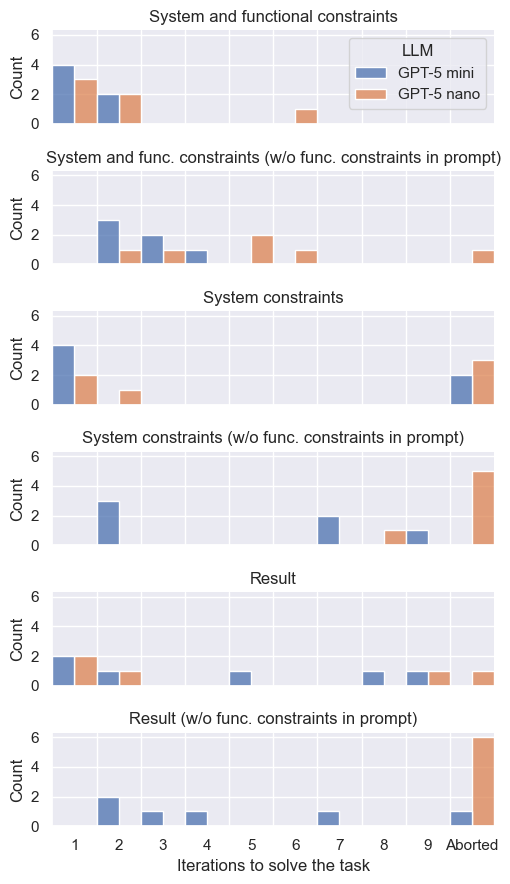

In [18]:
label_map = {
    "constraints_reasons": "System and functional constraints",
    "constraints_coverage": "System and func. constraints (w/o func. constraints in prompt)",
    "system_reasons": "System constraints",
    "system_coverage": "System constraints (w/o func. constraints in prompt)",
    "result_reasons": "Result",
    "result_coverage": "Result (w/o func. constraints in prompt)",
}
llm_map = {
    "5nano": "GPT-5 nano",
    "5mini": "GPT-5 mini",
}
iterations["params_label"] = iterations["params"].map(label_map)
iterations["llm_label"] = iterations["llm"].map(llm_map)

g = sns.displot(iterations, x="iterations", hue="llm_label", row="params_label", multiple="dodge", bins=np.arange(0.5, 11, 1), height=1.5, aspect=3.5, facet_kws={"legend_out": False, "xlim": (0.5, 10.5)}, row_order=list(label_map.values()))
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 11), labels=list(range(1, 10)) + ["Aborted"])
    ax.set_yticks(range(0, 7, 2))

    # minor ticks for grid lines between bars
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(1.5, 10.5, 1)))
    ax.tick_params(axis='x', which='minor', length=0)
    ax.grid(False, which='major', axis='x')
    ax.grid(True, which='minor', axis='x')

g.set_titles(row_template="{row_name}")
g.set_xlabels("Iterations to solve the task")
g._legend.set_title("LLM")

g.tight_layout()
plt.savefig(results_folder / "farm_hist_long.pdf", bbox_inches="tight")
plt.show()

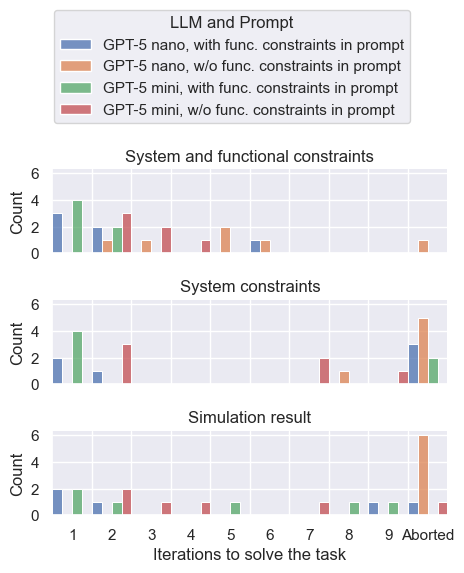

In [31]:
iterations[["variant", "prompt"]] = iterations["params"].str.split("_", expand=True)
variant_labels = {
    "constraints": "System and functional constraints",
    "system": "System constraints",
    "result": "Simulation result",
}
prompt_labels = {
    "reasons": "with func. constraints in prompt",
    "coverage": "w/o func. constraints in prompt",
}
iterations["variant_label"] = iterations["variant"].map(variant_labels)
iterations["prompt_label"] = iterations["prompt"].map(prompt_labels)
iterations["llm,prompt"] = iterations["llm_label"] + ", " + iterations["prompt_label"]
hue_order = [
    llm_map["5nano"] + ", " + prompt_labels["reasons"],
    llm_map["5nano"] + ", " + prompt_labels["coverage"],
    llm_map["5mini"] + ", " + prompt_labels["reasons"],
    llm_map["5mini"] + ", " + prompt_labels["coverage"]
]

g = sns.displot(iterations, x="iterations", hue="llm,prompt", row="variant_label", multiple="dodge", bins=np.arange(0.5, 11, 1), height=1.5, aspect=3.2, facet_kws={"legend_out": False, "xlim": (0.5, 10.5)}, row_order=list(variant_labels.values()), hue_order=hue_order)
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 11), labels=list(range(1, 10)) + ["Aborted"])
    ax.set_yticks(range(0, 7, 2))

    # minor ticks for grid lines between bars
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(1.5, 10.5, 1)))
    ax.tick_params(axis='x', which='minor', length=0)
    ax.grid(False, which='major', axis='x')
    ax.grid(True, which='minor', axis='x')

g.set_titles(row_template="{row_name}")
g.set_xlabels("Iterations to solve the task")
sns.move_legend(g, "lower center", bbox_to_anchor=(.5, 1), title="LLM and Prompt")

g.tight_layout()
plt.savefig(results_folder / "farm_hist.pdf", bbox_inches="tight")
plt.show()

### Damage

In [16]:
def last_value(row):
    value = 0
    for col in row.index:
        if not np.isnan(row[col]):
            value = row[col]
    return value

def is_pass(row):
    for col in row.index:
        constraints_col = col.replace('_result', '_all')
        if summary.loc[row.name, constraints_col] == "pass":
            return True
    return False

damage = plot_data.apply(lambda row: (last_value(row), is_pass(row)), axis=1, result_type="expand")
damage.rename(columns={0: "damage", 1: "passed"}, inplace=True)
damage

damage  passed
llm   params               repeat                
5mini constraints_coverage 01        54.3    True
                           02        83.0    True
                           03       115.7    True
                           04        71.3    True
                           05        54.3    True
...                                   ...     ...
5nano system_reasons       02        37.0    True
                           03       296.3   False
                           04       147.3   False
                           05        41.7    True
                           06       182.3   False

[72 rows x 2 columns]

In [17]:
damage[damage["passed"] == True]["damage"].describe()

count    48.0
mean     62.2
std      25.5
min      37.0
25%      48.8
50%      52.3
75%      63.6
max     129.3
Name: damage, dtype: float64